# Classification Trees

A classification tree is a supervised learning method used to predict categorical (qualitative) outcomes such as class labels (e.g.,signal / background or benign / malignant). It works by recursively splitting the dataset into smaller subsets based on feature values, where at each step the algorithm selects the best feature and an optimal threshold that produces the most homogeneous (pure) groups. Well the idea is to minimise mis-classification at each step.  The quality of a split is evaluated using impurity or misclassification measures such as the Gini index and entropy, defined as:

- Gini Index:  
  $$ Gini = 1 - \sum_{k=1}^{K} p_k^2 $$

- Entropy:  
  $$ Entropy = -\sum_{k=1}^{K} p_k \log_2 p_k $$

where \( p_k \) is the proportion of samples belonging to class \( k \) in a node. Lower values indicate better splits. Instead of directly minimizing classification error, the tree minimizes these impurity measures to make more effective decisions. The splitting process continues until certain stopping criteria are met, such as reaching a maximum depth (`max_depth`) or having too few samples at a node to allow further splitting (`min_samples_split`). The `criterion` parameter is used to choose the measure of impurity, such as Gini index or entropy, which determines how the quality (purity) of a split is evaluated. 
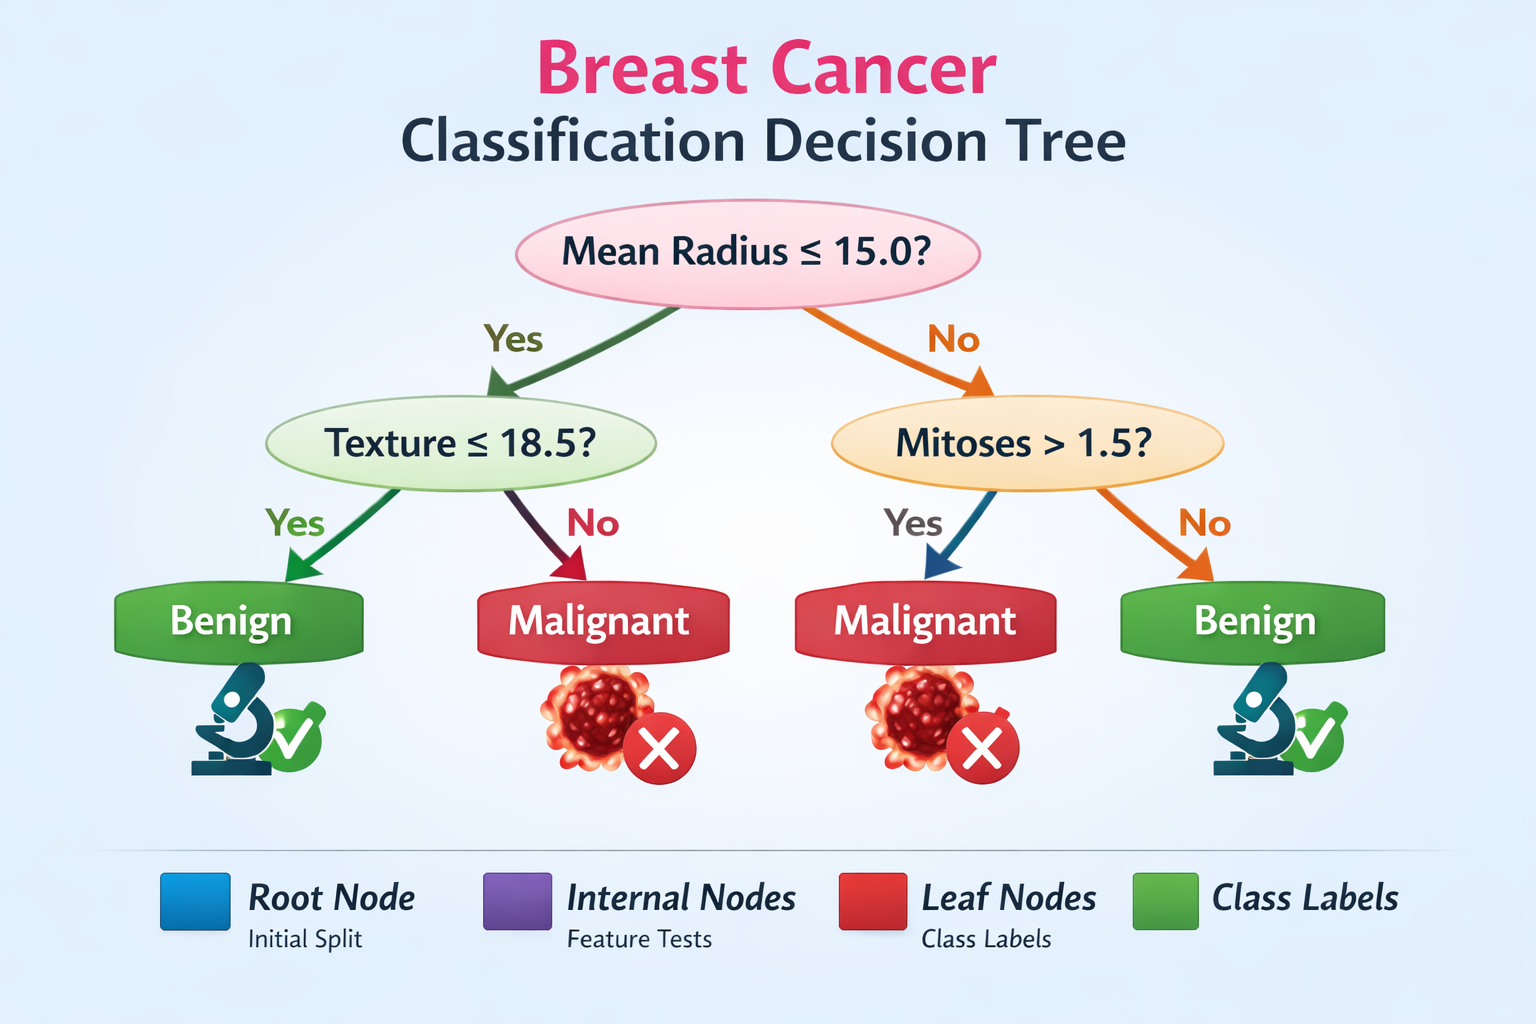

## Using scikitlearn library

In [6]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [7]:
data = load_breast_cancer()
X = data.data
dataset = pd.DataFrame(X, columns=data.feature_names)
dataset
Y = data.target

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.5)

In [9]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf = clf.fit(X_train,Y_train) 

In [10]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

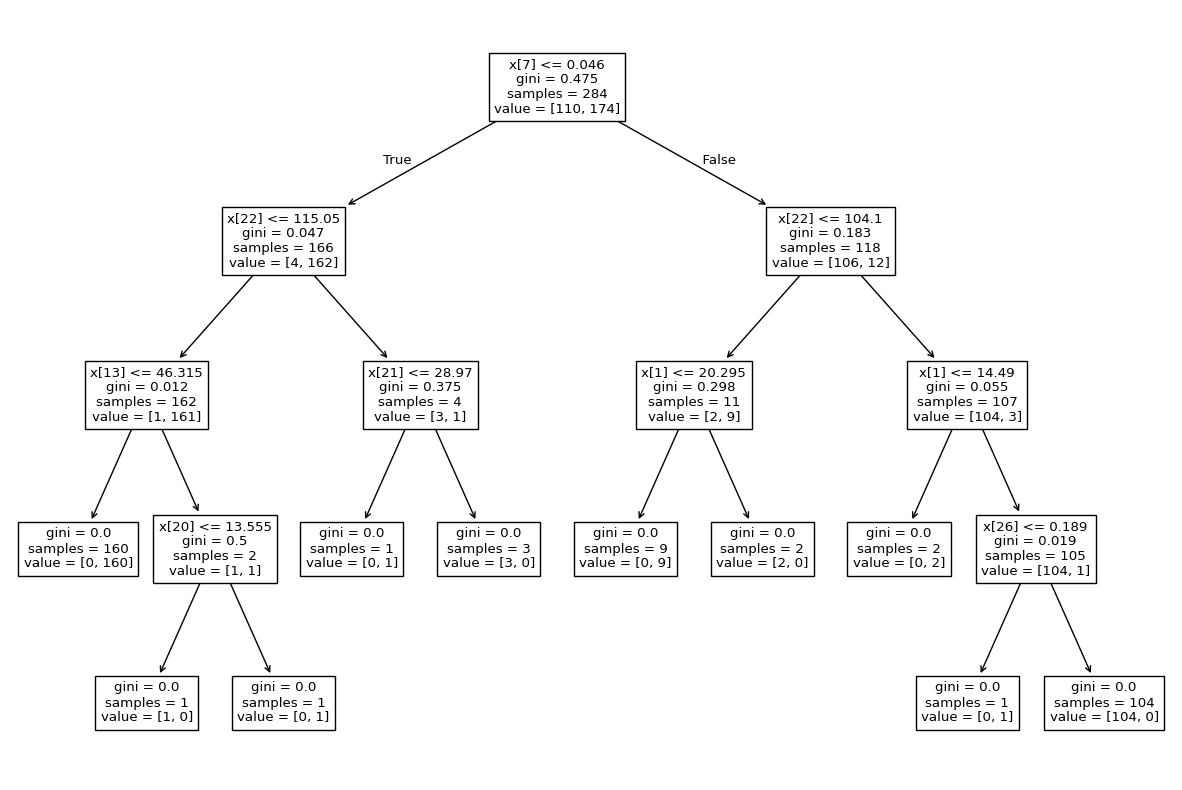

In [12]:
plt.figure(figsize=(15,10))
plot_tree(clf)
plt.show()

plt.figure(figsize=(20,12))

plot_tree(
    clf,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.show()

Accuracy Score: To measure the accuracy of the model, use trained model to predict outputs for test data and compare the predictions y_pred with true values Y_test. It measures how many predictions were correct out of total prediction

In [13]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
accuracy = accuracy_score(Y_test,y_pred)
print('accuracy: ', accuracy)

accuracy:  0.9087719298245615


Here 94.4% of the test observations are correctly classified. It is high because the tree is dense !

In order to detailed performance of the model, we can check the confusion table (similar to error matrix).

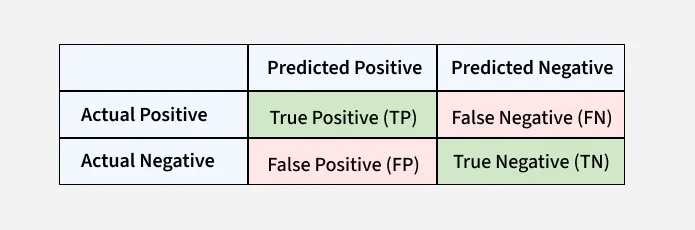

It measures all kinds of errors: false positive, false negative etc. Here Accuracy is just the sum of diagnol elements  divided by total i.e. (TP + TN) / (TP + FN + FP + TN). Precision score will tell us how many positive predictions made by the model were actually correct i.e. TP / (TP + FP).
The confusion matrix follows this structure:

[[TN  FP]

 [FN  TP]]
 |          | Predicted 0 | Predicted 1 |
| -------- | ----------- | ----------- |
| Actual 0 | TN          | FP          |
| Actual 1 | FN          | TP          |


In [14]:
print(data.target_names)
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test,y_pred)

['malignant' 'benign']


array([[ 83,  19],
       [  7, 176]])

In [15]:
from sklearn.metrics import precision_score
precision_score(Y_test,y_pred)

0.9025641025641026

In [16]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred,target_names=['malignant', 'benign']))

              precision    recall  f1-score   support

   malignant       0.92      0.81      0.86       102
      benign       0.90      0.96      0.93       183

    accuracy                           0.91       285
   macro avg       0.91      0.89      0.90       285
weighted avg       0.91      0.91      0.91       285



## Building Decision Trees from Scratch

In this section, we implement a Decision Tree classifier from scratch using only the NumPy library. The implementation is based on two main classes: `Node` and `DecisionTree`. Each Node stores information about the feature and threshold used to split the data, along with references to its left and right child nodes. Leaf nodes additionally store the predicted class label.

The core step in building the tree is finding the best split at each node. This is done using the `_best_split` function, which iterates over all features and their possible threshold values. For each candidate split, the information gain is computed using the difference between the entropy of the parent node and the weighted entropy of the child nodes. The split that maximizes this information gain is selected.

The `fit` function is used to train the decision tree by recursively growing the tree based on these optimal splits. Once trained, the predict function traverses the tree to assign class labels to new data points.

### Algorithm

The Decision Tree algorithm builds a tree structure by recursively splitting the dataset into smaller subsets based on feature values. The goal is to create nodes that are as **pure** as possible (i.e., contain samples of only one class).

#### **Step 1: Start with the full dataset**

* Begin at the root node with all training samples.
* Check stopping conditions:

  * Maximum depth reached
  * All samples belong to the same class
  * Number of samples is less than `min_samples_split`

If any condition is satisfied, create a **leaf node** with the most common label.

#### **Step 2: Find the best split**

* For each feature:

  * Extract all unique values as possible thresholds.
  * For each threshold:

    * Split the data into left and right subsets.
    * Compute **Information Gain**:

* Select the feature and threshold that **maximize the information gain**.


#### **Step 3: Split the dataset**

* Divide the dataset into:

  * Left child: values ≤ threshold
  * Right child: values > threshold

#### **Step 4: Recursively grow the tree**

* Apply the same process to left and right subsets:

  ```
  left = grow_tree(left_data)
  right = grow_tree(right_data)
  ```

* This continues until stopping criteria are met.




In [17]:
import numpy as np

class Node:

    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # only for leaf

    def is_leaf_node(self):
        if self.value is None:
            return False
        else:
            return True
    
class DecisionTree:

    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None 
        
    def fit(self, X, Y): # fit the tree using training data
        
        if self.n_features is None: 
            self.n_features = X.shape[1]

        else:
            self.n_features = min(X.shape[1], self.n_features) # needed for Random forest and to avoid features to be more than actual features/columns in X

        
        self.root = self._grow_tree(X,Y) #?

    def predict(self, X):

        predictions = []

        n_samples = X.shape[0]

        for i in range(n_samples):
            sample = X[i]
            pred = self._traverse_tree(sample, self.root)
            predictions.append(pred)

        return predictions

    
    def _traverse_tree(self, x, node):

        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x,node.left)

        return self._traverse_tree(x,node.right)
        
        
    def _grow_tree(self, X, Y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(Y))
        
        # check the stopping criteria
        if (depth >= self.max_depth or n_labels==1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(Y)
            return Node(value=leaf_value)

        # find the best split
        best_feature, best_thresh = self._best_split(X,Y)

        
        # create child nodes
        left_idxs, right_idxs = self._split(X[:,best_feature],best_thresh)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            leaf_value = self._most_common_label(Y)
            return Node(value=leaf_value)
    
        left = self._grow_tree(X[left_idxs], Y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs], Y[right_idxs], depth+1)

        return Node(best_feature, best_thresh, left, right, value=None)

    def _most_common_label(self, y):

        counts = {}

    # count frequencies
        for label in y:
            if label in counts:
                counts[label] += 1
            else:
                counts[label] = 1

        max_count = -1
        most_common = None

    # find label with max count
        for label, count in counts.items():
            if count > max_count:
                max_count = count
                most_common = label

        return most_common

                
    def _best_split(self, X, Y):

        best_gain = -1
        split_idx, split_threshold = None, None

        self.n_features = X.shape[1]
        for feat_idx in range(self.n_features):
            
            X_column = X[:,feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                # calculate the information gain
                gain = self._information_gain(Y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr


        return split_idx, split_threshold

    def _information_gain(self, y, X_column, thr):

        # calculate parent entropy
        parent_entropy = self._entropy(y)
        

        # create children
        left_idxs, right_idxs = self._split(X_column, thr)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # calculate weighted avg. entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]),  self._entropy(y[right_idxs])

        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r
        
        # calculate the IG
        information_gain = parent_entropy - child_entropy

        return information_gain
        
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)

        entr = 0
        for p in ps:
            if p > 0:
                entr -= p * np.log(p)

        return entr
        
    
    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs


In [18]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np

#from DecisionTree import DecisionTree

# load data
data = datasets.load_breast_cancer()
X, y = data.data, data.target

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

# model
clf = DecisionTree()
# train
clf.fit(X_train, y_train)

# predict
predictions = np.array(clf.predict(X_test))

# accuracy
def accuracy(y_test, y_pred):
    return np.sum(y_test == y_pred) / len(y_test)

acc = accuracy(y_test, predictions)
print(acc)


0.9122807017543859
